<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Módulo 1:  Modelo CBOW (WordEmbeddings)</h1>
    <h2>Word Embeddings</h2>
</div>

En esta archivo de jupyter, obtendremos un modelo de CBOW desde cero para generar los wordembeddings. Saber cómo entrenar estos modelos nos brindará una mejor comprensión de los vectores palabras, que son los componentes básicos de muchas aplicaciones en el procesamiento del lenguaje natural.

<a name='1'></a>
# Continuous bag of words (CBOW)

Observemos la siguiente sentencia: 
>**'I am happy because I am learning'**. 

- Como lo vimos en la clase pasada, en el modelado de bolsa continua de palabras (CBOW), intentamos predecir la palabra central dadas algunas palabras de contexto (las palabras alrededor de la palabra central).

- Por ejemplo, si tuviera que elegir un contexto de tamaño medio, digamos $C = 2$, entonces intentaría predecir la palabra **happy** dado el contexto que incluye 2 palabras antes y 2 palabras después de la palabra central. :

> $C$ palabras antes: [I, am] 

> $C$ palabras después: [because, I] 

- en otras palabras el vector contexto, y el vector target quedarían como:

$$context = [I,am, because, I]$$
$$target = happy$$

Una estructura simple del modelo se ve como sigue:

<div style="width:image width px; font-size:100%; text-align:center;"><img src='Figures/word2.png' alt="alternate text" width="width" height="height" style="width:600px;height:250px;" /></div>

donde $\bar x$ es el promedio de todos los vectores one-hot de las palabras de contexto.

<div style="width:image width px; font-size:100%; text-align:center;"><img src='Figures/mean_vec2.png' alt="alternate text" width="width" height="height" style="width:600px;height:250px;" />  </div>

Una vez que ya tenemos los vectores contextos, podemos usar $\bar x$  como la entrada al modelo 

La arquitectura a implementar es la siguiente:

\begin{align}
 h &= W_1 \  X + b_1  \tag{1} \\
 a &= ReLU(h)  \tag{2} \\
 z &= W_2 \  a + b_2   \tag{3} \\
 \hat y &= softmax(z)   \tag{4} \\
\end{align}

In [1]:
# Import Python libraries and helper functions (in utils2) 
import nltk
from nltk.tokenize import word_tokenize
import numpy as np
from collections import Counter
from utils2 import sigmoid, get_batches, compute_pca, get_dict
from NLP_TextCleaner import TextCleaningPipeline

In [2]:
# Download sentence tokenizer
nltk.data.path.append('.')

In [3]:
# Load, tokenize and process the data
import re                                                           # Cargando los datos del archivo de texto
with open('Data/shakespeare.txt') as f:
    data = f.read()

In [4]:
data

'O for a Muse of fire, that would ascend\nThe brightest heaven of invention,\nA kingdom for a stage, princes to act\nAnd monarchs to behold the swelling scene!\nThen should the warlike Harry, like himself,\nAssume the port of Mars; and at his heels,\nLeash\'d in like hounds, should famine, sword and fire\nCrouch for employment. But pardon, and gentles all,\nThe flat unraised spirits that have dared\nOn this unworthy scaffold to bring forth\nSo great an object: can this cockpit hold\nThe vasty fields of France? or may we cram\nWithin this wooden O the very casques\nThat did affright the air at Agincourt?\nO, pardon! since a crooked figure may\nAttest in little place a million;\nAnd let us, ciphers to this great accompt,\nOn your imaginary forces work.\nSuppose within the girdle of these walls\nAre now confined two mighty monarchies,\nWhose high upreared and abutting fronts\nThe perilous narrow ocean parts asunder:\nPiece out our imperfections with your thoughts;\nInto a thousand parts d

In [5]:
data = re.sub(r'[,!?;-]', '.',data)                                 #simbolos de punctuacion es remplazado por .
tokens_data = nltk.word_tokenize(data)                                     #  Tokenizacion usando nltk 
tokens_data = [ch.lower() for ch in tokens_data if ch.isalpha() or ch == '.']     #  Normalización de los tokens
print(f"Número total de tokens:{len(tokens_data)} \n Ejemplo de un token en posición 15: {tokens_data[:15]}")         #  print data sample

Número total de tokens:61011 
 Ejemplo de un token en posición 15: ['o', 'for', 'a', 'muse', 'of', 'fire', '.', 'that', 'would', 'ascend', 'the', 'brightest', 'heaven', 'of', 'invention']


In [6]:
# Calculamos la distribución de frecuenciaas de palabras en el corpus
fdist = nltk.FreqDist(word for word in tokens_data)
vocabulario = set(tokens_data)
n_vocabulario = len(fdist)
print("Tamaño del vocabulario: ",n_vocabulario)
print("Los tokens más frecuentes: ",fdist.most_common(20) ) 

Tamaño del vocabulario:  5784
Los tokens más frecuentes:  [('.', 9630), ('the', 1521), ('and', 1394), ('i', 1259), ('to', 1159), ('of', 1093), ('my', 857), ('that', 781), ('in', 771), ('a', 752), ('you', 748), ('is', 630), ('not', 559), ('for', 467), ('it', 460), ('with', 441), ('his', 434), ('but', 417), ('me', 417), ('your', 397)]


#### Mapear las palabras a sus indices y de indices a palabras


In [7]:
# obtener los diccionarios palabras vs indices, indices vs palabras
word2Ind, Ind2word = get_dict(tokens_data)   #get_dic función en librería utils2


In [8]:
Ind2word

{0: '.',
 1: 'a',
 2: 'abandon',
 3: 'abed',
 4: 'abhor',
 5: 'abhorr',
 6: 'abide',
 7: 'abides',
 8: 'ability',
 9: 'able',
 10: 'abode',
 11: 'about',
 12: 'above',
 13: 'abroad',
 14: 'absence',
 15: 'absent',
 16: 'absolute',
 17: 'abstract',
 18: 'abundance',
 19: 'abundant',
 20: 'abus',
 21: 'abuse',
 22: 'abused',
 23: 'abuses',
 24: 'abutting',
 25: 'abysm',
 26: 'accents',
 27: 'acceptance',
 28: 'accessary',
 29: 'accident',
 30: 'accidents',
 31: 'accomplish',
 32: 'accomplishment',
 33: 'accompt',
 34: 'accordingly',
 35: 'account',
 36: 'accumulate',
 37: 'accus',
 38: 'accuse',
 39: 'accusing',
 40: 'achieve',
 41: 'achieves',
 42: 'acknowledge',
 43: 'acordo',
 44: 'acquaint',
 45: 'acquaintance',
 46: 'acquainted',
 47: 'acquir',
 48: 'across',
 49: 'act',
 50: 'action',
 51: 'actions',
 52: 'active',
 53: 'actor',
 54: 'acts',
 55: 'acutely',
 56: 'adam',
 57: 'add',
 58: 'added',
 59: 'adder',
 60: 'addeth',
 61: 'addiction',
 62: 'adding',
 63: 'addition',
 64: 'ad

In [9]:
word2Ind

{'.': 0,
 'a': 1,
 'abandon': 2,
 'abed': 3,
 'abhor': 4,
 'abhorr': 5,
 'abide': 6,
 'abides': 7,
 'ability': 8,
 'able': 9,
 'abode': 10,
 'about': 11,
 'above': 12,
 'abroad': 13,
 'absence': 14,
 'absent': 15,
 'absolute': 16,
 'abstract': 17,
 'abundance': 18,
 'abundant': 19,
 'abus': 20,
 'abuse': 21,
 'abused': 22,
 'abuses': 23,
 'abutting': 24,
 'abysm': 25,
 'accents': 26,
 'acceptance': 27,
 'accessary': 28,
 'accident': 29,
 'accidents': 30,
 'accomplish': 31,
 'accomplishment': 32,
 'accompt': 33,
 'accordingly': 34,
 'account': 35,
 'accumulate': 36,
 'accus': 37,
 'accuse': 38,
 'accusing': 39,
 'achieve': 40,
 'achieves': 41,
 'acknowledge': 42,
 'acordo': 43,
 'acquaint': 44,
 'acquaintance': 45,
 'acquainted': 46,
 'acquir': 47,
 'across': 48,
 'act': 49,
 'action': 50,
 'actions': 51,
 'active': 52,
 'actor': 53,
 'acts': 54,
 'acutely': 55,
 'adam': 56,
 'add': 57,
 'added': 58,
 'adder': 59,
 'addeth': 60,
 'addiction': 61,
 'adding': 62,
 'addition': 63,
 'additi

In [10]:
# example of word to index mapping
print("Indice de la palabra 'king' :  ",word2Ind['king'] )
print("Palabra cuyo indice es 2743:  ",Ind2word[2743] )

Indice de la palabra 'king' :   2747
Palabra cuyo indice es 2743:   kind


<a name='2'></a>
# Entrenando el Modelo

###  Inicialización del modelo

Ahora inicializaremos dos matrices y dos vectores.
- La primera matriz ($W_1$) es de dimensión $N \times V$, donde $V$ es el número de palabras en tu vocabulario y $N$ es la dimensión de tu vector de palabras.
- La segunda matriz ($W_2$) es de dimensión $V \times N$.
- El vector $b_1$ tiene dimensiones $N\times 1$
- El vector $b_2$ tiene dimensiones $V\times 1$.
- $b_1$ y $b_2$ son los vectores bias.

La estructura general del modelo se verá como en la Figura 1, pero en esta etapa solo estamos inicializando los parámetros.


In [11]:
def initialize_model(N,V, random_seed=1):
    np.random.seed(random_seed)
    # W1 con shape (N,V)
    W1 = np.random.rand(N,V)
    # W2 con shape (V,N)
    W2 = np.random.rand(V,N)
    # b1 con shape (N,1)
    b1 = np.random.rand(N,1)
    # b2 con shape (V,1)
    b2 = np.random.rand(V,1)
    
    return W1, W2, b1, b2

In [12]:
# Probamos la inicialización
tmp_N = 4
tmp_V = 10
tmp_W1, tmp_W2, tmp_b1, tmp_b2 = initialize_model(tmp_N,tmp_V)
print(f"tmp_W1.shape: {tmp_W1.shape}")
print(f"tmp_W2.shape: {tmp_W2.shape}")
print(f"tmp_b1.shape: {tmp_b1.shape}")
print(f"tmp_b2.shape: {tmp_b2.shape}")

tmp_W1.shape: (4, 10)
tmp_W2.shape: (10, 4)
tmp_b1.shape: (4, 1)
tmp_b2.shape: (10, 1)


<a name='2.1'></a>
### 2.1 Softmax
Antes de que podamos comenzar a entrenar el modelo, debemos implementar la función softmax:  

<br>
$$ \text{softmax}(z_i) = \frac{e^{z_i} }{\sum_{i=0}^{V-1} e^{z_i} }  $$

- $V$ es el número de palabras en el vocabulario (que también es el número de filas de $z$).
- $i$ va de 0 a |V| - 1.


**Implementando la función softmax.**

- Supongamos que la entrada $z$ a `softmax` es una matriz 2D
- Cada ejemplo de entrenamiento está representado por una columna de forma (V, 1) en esta matriz 2D.
- Puede haber más de una columna en la matriz 2D, porque puede incluir un lote de ejemplos para aumentar la eficiencia. Llamemos al tamaño del lote $m$ en minúsculas, por lo que la matriz $z$ tiene la forma (V, m)
- Al tomar la suma de $i=1 \cdots V-1$, toma la suma de cada columna (cada ejemplo) por separado.


In [14]:
def softmax(z):
    # Calcular yhat (softmax)
    e_z = np.exp(z)
    yhat = e_z/np.sum(e_z,axis=0)    
    return yhat

In [15]:
# Probando la función
tmp = np.array([[1,2,3],
                [1,1,1]
               ])
tmp_sm = softmax(tmp)
display(tmp_sm)

array([[0.5       , 0.73105858, 0.88079708],
       [0.5       , 0.26894142, 0.11920292]])

<a name='2.2'></a>
### Forward propagation

Implementemos la propagación directa $z$ según las ecuaciones. <br>

\begin{align}
 h &= W_1 \  X + b_1   \\
 a &= ReLU(h)   \\
 z &= W_2 \  a + b_2   \\
\end{align}

Para ello utilizaremos como función de activación la ReLU dada por:

$$f(h)=\max (0,h) \tag{6}$$

In [17]:
def forward_prop(x, W1, W2, b1, b2):
    # Calculando h
    h = np.dot(W1,x)+b1
    
    # Aplicamos la función de activaación relu
    h = np.maximum(0,h)
    
    # Caalculando z
    z = np.dot(W2,h)+b2

    return z, h

In [18]:
# Probando la función de forward_prop

# Creamos algunas entradas para probar la función

tmp_N = 2    #Numero de neuronas en capa oculta
tmp_V = 3    # tamaño del vocabulario

tmp_x = np.array([[0,1,0]]).T   # ejemplo de la representación de alguna palabra en el vocabulario

#Inicializamos la red
tmp_W1, tmp_W2, tmp_b1, tmp_b2 = initialize_model(N=tmp_N,V=tmp_V, random_seed=1)

print(f"x tiene un shape {tmp_x.shape}")
print(f"N es {tmp_N} y el tamaño del vocabulario V es {tmp_V}")

# llamando la función forward propagation
tmp_z, tmp_h = forward_prop(tmp_x, tmp_W1, tmp_W2, tmp_b1, tmp_b2)

#Veamos la salida
print(f"z tiene shape {tmp_z.shape}")
print(f"z contiene los valores:\n{tmp_z}")
print()
print(f"h tiene shape {tmp_h.shape}")
print("h tiene valores:")
print(tmp_h)

x tiene un shape (3, 1)
N es 2 y el tamaño del vocabulario V es 3
z tiene shape (3, 1)
z contiene los valores:
[[0.55379268]
 [1.58960774]
 [1.50722933]]

h tiene shape (2, 1)
h tiene valores:
[[0.92477674]
 [1.02487333]]



## Función de Costo


$$ J = -\frac{1}{n}\sum\limits_{k=1}^{V} y_k \log{\hat{y}_k} + (1-y_k)\log({1-{\hat{y}_k}})$$

In [19]:
# Función de costo de entropía para clasificación
def compute_cost(y, yhat, batch_size):
    # cost function 
    logprobs = np.multiply(np.log(yhat),y) + np.multiply(np.log(1 - yhat), 1 - y)
    cost = - 1/batch_size * np.sum(logprobs)
    cost = np.squeeze(cost)
    return cost

In [20]:
# Probando las funciones nuevamente
tmp_C = 2    
tmp_N = 50
tmp_batch_size = 4
tmp_word2Ind, tmp_Ind2word = get_dict(tokens_data)
tmp_V = len(word2Ind)

tmp_x, tmp_y = next(get_batches(tokens_data, tmp_word2Ind, tmp_V, tmp_C, tmp_batch_size))
        
print(f"tmp_x.shape {tmp_x.shape}")
print(f"tmp_y.shape {tmp_y.shape}")

tmp_W1, tmp_W2, tmp_b1, tmp_b2 = initialize_model(tmp_N,tmp_V)

print(f"tmp_W1.shape {tmp_W1.shape}")
print(f"tmp_W2.shape {tmp_W2.shape}")
print(f"tmp_b1.shape {tmp_b1.shape}")
print(f"tmp_b2.shape {tmp_b2.shape}")

tmp_z, tmp_h = forward_prop(tmp_x, tmp_W1, tmp_W2, tmp_b1, tmp_b2)
print(f"tmp_z.shape: {tmp_z.shape}")
print(f"tmp_h.shape: {tmp_h.shape}")

tmp_yhat = softmax(tmp_z)
print(f"tmp_yhat.shape: {tmp_yhat.shape}")

tmp_cost = compute_cost(tmp_y, tmp_yhat, tmp_batch_size)
print("Llamamos a la función de costo (compute_cost)")
print(f"tmp_cost {tmp_cost:.4f}")

tmp_x.shape (5784, 4)
tmp_y.shape (5784, 4)
tmp_W1.shape (50, 5784)
tmp_W2.shape (5784, 50)
tmp_b1.shape (50, 1)
tmp_b2.shape (5784, 1)
tmp_z.shape: (5784, 4)
tmp_h.shape: (50, 4)
tmp_yhat.shape: (5784, 4)
Llamamos a la función de costo (compute_cost)
tmp_cost 12.8492


In [21]:
tmp_x

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], shape=(5784, 4))

In [22]:
tmp_y

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], shape=(5784, 4))

In [23]:
tmp_z

array([[20.35836896, 20.35836896, 20.35836896, 20.35836896],
       [22.76630639, 22.76630639, 22.76630639, 22.76630639],
       [24.72302518, 24.72302518, 24.72302518, 24.72302518],
       ...,
       [25.11712497, 25.11712497, 25.11712497, 25.11712497],
       [26.03707299, 26.03707299, 26.03707299, 26.03707299],
       [22.52074116, 22.52074116, 22.52074116, 22.52074116]],
      shape=(5784, 4))

In [24]:
tmp_yhat

array([[6.44669418e-07, 6.44669418e-07, 6.44669418e-07, 6.44669418e-07],
       [7.16293498e-06, 7.16293498e-06, 7.16293498e-06, 7.16293498e-06],
       [5.06854353e-05, 5.06854353e-05, 5.06854353e-05, 5.06854353e-05],
       ...,
       [7.51689607e-05, 7.51689607e-05, 7.51689607e-05, 7.51689607e-05],
       [1.88610946e-04, 1.88610946e-04, 1.88610946e-04, 1.88610946e-04],
       [5.60329365e-06, 5.60329365e-06, 5.60329365e-06, 5.60329365e-06]],
      shape=(5784, 4))

In [25]:
tmp_V

5784


## Training the Model - Backpropagation

Ahora entrenaremos el modelo CBOW <br>
Creamos una función para la propagación hacia adelante. Ahora implementaremos una función que calcula los gradientes para propagar los errores hacia atrás.

In [26]:
def relu(z):
    result = z.copy()
    result[result<0]=0
    return result

In [28]:
l1=np.array([[0.52727857,  0.52727857,  0.52727857,  0.52727857],
 [-0.1259346,  -0.1259346,  -0.1259346 , -0.1259346 ],
 [ 0.39739328,  0.39739328,  0.39739328,  0.39739328],
 [-0.33644763, -0.33644763, -0.33644763, -0.33644763]])

In [29]:
new_array = np.apply_along_axis(relu, 0, l1)
new_array

array([[0.52727857, 0.52727857, 0.52727857, 0.52727857],
       [0.        , 0.        , 0.        , 0.        ],
       [0.39739328, 0.39739328, 0.39739328, 0.39739328],
       [0.        , 0.        , 0.        , 0.        ]])

Las formulas que necesitamos para implementar el backpropagation son:


\begin{align}
 \frac{\partial J}{\partial \mathbf{W_1}} &= \rm{ReLU}\left ( \mathbf{W_2^\top} (\mathbf{\hat{y}} - \mathbf{y})\right )\mathbf{x}^\top \\
 \frac{\partial J}{\partial \mathbf{W_2}} &= (\mathbf{\hat{y}} - \mathbf{y})\mathbf{h^\top} \\
 \frac{\partial J}{\partial \mathbf{b_1}} &= \rm{ReLU}\left ( \mathbf{W_2^\top} (\mathbf{\hat{y}} - \mathbf{y})\right ) \\
 \frac{\partial J}{\partial \mathbf{b_2}} &= \mathbf{\hat{y}} - \mathbf{y} 
\end{align}


In [30]:
def back_prop(x, yhat, y, h, W1, W2, b1, b2, batch_size):

    # Calcular l1 as W2^T (Yhat - Y)
    #  W2^T (Yhat - Y) 
    l1 = np.dot(W2.T,(yhat-y))
    # Apply relu to l1
    l1 = np.apply_along_axis(relu, 0, l1)
    # Calcular el gradient of W1
    grad_W1 = (1/batch_size)*np.dot(l1,x.T) 
    # Calcular el gradient of W2
    grad_W2 = (1/batch_size)*np.dot(yhat-y,h.T)
    # Calcular el gradient of b1
    grad_b1 = np.sum((1/batch_size)*np.dot(l1,x.T),axis=1,keepdims=True)
    # Calcular el gradient of b2
    grad_b2 = np.sum((1/batch_size)*np.dot(yhat-y,h.T),axis=1,keepdims=True)
    
    return grad_W1, grad_W2, grad_b1, grad_b2

In [31]:
# Probar la función
tmp_C = 2
tmp_N = 50
tmp_batch_size = 4
tmp_word2Ind, tmp_Ind2word = get_dict(data)
tmp_V = len(word2Ind)

# get a batch of data
tmp_x, tmp_y = next(get_batches(data, tmp_word2Ind, tmp_V,tmp_C, tmp_batch_size))

print("Tomando un batch de losd datos")
print(f"tmp_x.shape {tmp_x.shape}")
print(f"tmp_y.shape {tmp_y.shape}")

print()
print("Inicializando los pesos y los bias")
tmp_W1, tmp_W2, tmp_b1, tmp_b2 = initialize_model(tmp_N,tmp_V)

print(f"tmp_W1.shape {tmp_W1.shape}")
print(f"tmp_W2.shape {tmp_W2.shape}")
print(f"tmp_b1.shape {tmp_b1.shape}")
print(f"tmp_b2.shape {tmp_b2.shape}")

print()
print("Aplicando Forwad prop para obtener z y h")
tmp_z, tmp_h = forward_prop(tmp_x, tmp_W1, tmp_W2, tmp_b1, tmp_b2)
print(f"tmp_z.shape: {tmp_z.shape}")
print(f"tmp_h.shape: {tmp_h.shape}")

print()
print("Obtenemos yhat llamando la función de activación por softmax")
tmp_yhat = softmax(tmp_z)
print(f"tmp_yhat.shape: {tmp_yhat.shape}")

tmp_m = (2*tmp_C)
tmp_grad_W1, tmp_grad_W2, tmp_grad_b1, tmp_grad_b2 = back_prop(tmp_x, tmp_yhat, tmp_y, tmp_h, tmp_W1, tmp_W2, tmp_b1, tmp_b2, tmp_batch_size)

print()
print("call back_prop")
print(f"tmp_grad_W1.shape {tmp_grad_W1.shape}")
print(f"tmp_grad_W2.shape {tmp_grad_W2.shape}")
print(f"tmp_grad_b1.shape {tmp_grad_b1.shape}")
print(f"tmp_grad_b2.shape {tmp_grad_b2.shape}")

Tomando un batch de losd datos
tmp_x.shape (5784, 4)
tmp_y.shape (5784, 4)

Inicializando los pesos y los bias
tmp_W1.shape (50, 5784)
tmp_W2.shape (5784, 50)
tmp_b1.shape (50, 1)
tmp_b2.shape (5784, 1)

Aplicando Forwad prop para obtener z y h
tmp_z.shape: (5784, 4)
tmp_h.shape: (50, 4)

Obtenemos yhat llamando la función de activación por softmax
tmp_yhat.shape: (5784, 4)

call back_prop
tmp_grad_W1.shape (50, 5784)
tmp_grad_W2.shape (5784, 50)
tmp_grad_b1.shape (50, 1)
tmp_grad_b2.shape (5784, 1)



## Gradient Descent

Ahora que hemos implementado una función para calcular los gradientes, implementaremos el descenso de gradientes por **lotes** en su conjunto de entrenamiento.

Para esto, usaremos `initialize_model` y las funciones `back_prop` que acabamos de crear (y la función `compute_cost`). También podemos utilizar la función auxiliar `get_batches`:

```
for x, y in get_batches(data, word2Ind, V, C, batch_size):```

```...```


Durante la fase del gradiante descendente, se actualizarán los pesos y los bías $ \alpha $ veces el gradiente de las matrices y vectores originales, utilizando las siguientes fórmulas.


\begin{align}
 \mathbf{W_1} &:= \mathbf{W_1} - \alpha \frac{\partial J}{\partial \mathbf{W_1}} \\
 \mathbf{W_2} &:= \mathbf{W_2} - \alpha \frac{\partial J}{\partial \mathbf{W_2}} \\
 \mathbf{b_1} &:= \mathbf{b_1} - \alpha \frac{\partial J}{\partial \mathbf{b_1}}\\
 \mathbf{b_2} &:= \mathbf{b_2} - \alpha \frac{\partial J}{\partial \mathbf{b_2}} \\
\end{align}


In [32]:
def gradient_descent(data, word2Ind, N, V, num_iters, alpha=0.03):

    W1, W2, b1, b2 = initialize_model(N,V, random_seed=282)
    batch_size = 128
    iters = 0
    C = 2
    for x, y in get_batches(data, word2Ind, V, C, batch_size):
        # Obtenemos z and h
        z, h = forward_prop(x, W1, W2, b1, b2)
        # Obteniendo yhat
        yhat = softmax(z)
        # calculando la función de costo
        cost = compute_cost(y, yhat, batch_size)
        if ( (iters+1) % 10 == 0):
            print(f"iters: {iters + 1} cost: {cost:.6f}")
        # Obteniendo los gradientes
        grad_W1, grad_W2, grad_b1, grad_b2 = back_prop(x, yhat, y, h, W1, W2, b1, b2, batch_size)
        
        # Actualizando los pesos
        W1 -= alpha*grad_W1 
        W2 -= alpha*grad_W2
        b1 -= alpha*grad_b1
        b2 -= alpha*grad_b2
        
        iters += 1 
        if iters == num_iters: 
            break
        if iters % 100 == 0:
            alpha *= 0.66
            
    return W1, W2, b1, b2

In [33]:
# Probando la función
C = 2
N = 50
word2Ind, Ind2word = get_dict(tokens_data)
V = len(word2Ind)
num_iters = 150
print("Call gradient_descent")
W1, W2, b1, b2 = gradient_descent(tokens_data, word2Ind, N, V, num_iters)

Call gradient_descent
iters: 10 cost: 0.107644
iters: 20 cost: 0.042388
iters: 30 cost: 0.026480
iters: 40 cost: 0.019272
iters: 50 cost: 0.015155
iters: 60 cost: 0.012490
iters: 70 cost: 0.010624
iters: 80 cost: 0.009244
iters: 90 cost: 0.008182
iters: 100 cost: 0.007339
iters: 110 cost: 0.006850
iters: 120 cost: 0.006442
iters: 130 cost: 0.006080
iters: 140 cost: 0.005757
iters: 150 cost: 0.005466



## Visualización de los vectores palabra
En esta parte visualizaremos los vectores de palabras entrenados usando la función que acabas de codificar arriba.

#### Opción 1: extraer los embeddings de W1

In [34]:
for i in range(V):
    print(Ind2word[i])

.
a
abandon
abed
abhor
abhorr
abide
abides
ability
able
abode
about
above
abroad
absence
absent
absolute
abstract
abundance
abundant
abus
abuse
abused
abuses
abutting
abysm
accents
acceptance
accessary
accident
accidents
accomplish
accomplishment
accompt
accordingly
account
accumulate
accus
accuse
accusing
achieve
achieves
acknowledge
acordo
acquaint
acquaintance
acquainted
acquir
across
act
action
actions
active
actor
acts
acutely
adam
add
added
adder
addeth
addiction
adding
addition
additions
address
adieu
adjacent
adjunct
admir
admirable
admiration
admire
admired
admiring
admiringly
admit
admitted
adonis
adoption
adoptious
adore
adornings
adulterate
advanc
advance
advantage
advantages
adversaries
adversary
adverse
advertisement
advice
advise
advised
advocate
afar
afeard
affable
affairs
affect
affection
affections
affects
affirm
afford
affords
affright
afloat
afoot
afraid
afresh
after
afternoon
afterward
afterwards
again
against
age
aged
ages
aggravate
agincourt
agrippa
ah
aid
aiding

In [35]:
V

5784

In [36]:
W1.T.shape

(5784, 50)

In [37]:
W1.T

array([[0.36842629, 0.76289743, 0.30410829, ..., 0.17790178, 0.75029121,
        0.13126347],
       [0.39172236, 0.40617587, 0.39310469, ..., 0.89466596, 0.43969283,
        0.52527444],
       [0.12117024, 0.55198011, 0.6595233 , ..., 0.16303259, 0.35028232,
        0.76925114],
       ...,
       [0.44399331, 0.0011731 , 0.87277114, ..., 0.77298328, 0.6858097 ,
        0.28647368],
       [0.31300743, 0.76079736, 0.8016032 , ..., 0.04298577, 0.86794787,
        0.20341079],
       [0.10089291, 0.09492807, 0.11991296, ..., 0.20840872, 0.93451275,
        0.22831177]], shape=(5784, 50))

In [38]:
words = ['lord','man', 'woman']
idx = [word2Ind[word] for word in words]
for i in idx:
    print(f'{Ind2word[i]} -----> {W1.T[i,:]}')

lord -----> [2.39213652e-02 3.87538784e-01 1.11836157e-01 2.81430817e-01
 2.38426090e-01 9.93584354e-01 2.03937160e-01 9.96870016e-01
 5.02762653e-01 8.49682498e-01 2.64263184e-02 6.16524863e-01
 2.90826392e-02 8.07122156e-01 3.50328269e-01 7.80988568e-01
 1.10133712e-02 5.59991694e-01 4.92783048e-01 3.62318025e-01
 8.94720468e-01 8.13893345e-01 3.10585087e-01 8.13570281e-01
 7.75438185e-01 9.45777731e-01 6.55912877e-01 6.74091220e-01
 1.00098643e-02 4.13659216e-01 7.73566280e-01 4.50468302e-01
 4.11015367e-05 9.20146441e-01 8.70835404e-01 5.39436452e-01
 9.00315440e-01 6.37005609e-01 3.87681720e-01 5.24343272e-01
 1.66735054e-01 5.54662463e-01 7.85137519e-01 7.84421320e-01
 9.86007125e-01 3.39051425e-02 2.97834779e-01 4.72399322e-01
 9.86061977e-01 4.68951648e-01]
man -----> [0.15280853 0.28544154 0.6466387  0.23239636 0.42026731 0.47844997
 0.60472542 0.21492557 0.03234024 0.79484508 0.39429784 0.01062169
 0.75415878 0.44845862 0.33551988 0.54000752 0.74602207 0.87234637
 0.40527671 

#### Opción 2: extraer los embeddings de W2

In [39]:
W2.shape

(5784, 50)

In [40]:
words = ['lord','man', 'woman']
idx = [word2Ind[word] for word in words]
for i in idx:
    print(f'{Ind2word[i]} -----> {W2[i,:]}')

lord -----> [0.22276781 0.17046835 0.77755126 0.69677337 0.53497356 0.15882557
 0.81695926 0.30081047 0.61550625 0.76868004 0.4117644  0.65001815
 0.5646408  0.11736362 0.17375084 0.01567015 0.31425001 0.26087007
 0.58208246 0.3369812  0.94000249 0.45928298 0.89356675 0.62869292
 0.08025145 0.0788468  0.25847499 0.89157947 0.59558783 0.09884915
 0.26789238 0.54864081 0.76313076 0.83734225 0.53461791 0.36127556
 0.96964791 0.29027033 0.6145604  0.02197722 0.54882713 0.48960786
 0.45346846 0.92390883 0.96429132 0.20635015 0.79447231 0.81860311
 0.90495964 0.50868861]
man -----> [0.55428179 0.12653618 0.49729512 0.32186004 0.42775489 0.37169793
 0.03098263 0.12276142 0.44146976 0.69986275 0.69890692 0.14270079
 0.90663743 0.29530464 0.69667463 0.67778047 0.49010414 0.99462332
 0.17318291 0.06396459 0.12659338 0.96730704 0.51232897 0.53376685
 0.41398543 0.56723243 0.00398383 0.30774908 0.77618106 0.47932072
 0.37025984 0.65164296 0.86956256 0.74140499 0.93450076 0.50358365
 0.13989732 0.2

#### Opción 3: extraer los embeddings de W1 y W2

In [41]:
# visualizing the word vectors here
from matplotlib import pyplot
%config InlineBackend.figure_format = 'svg'
words = ['king', 'queen','lord','man', 'woman','dog','wolf',
         'rich','happy','sad']

#Vector de palabras (embeddings)
word_embs = (W1.T + W2)/2.0
 
# given a list of words and the embeddings, it returns a matrix with all the embeddings
idx = [word2Ind[word] for word in words]
X = word_embs[idx, :]
print(X.shape, idx)  # X.shape:  Number of words of dimension N each 

(10, 50) [2747, 3953, 2963, 3025, 5681, 1455, 5680, 4193, 2318, 4281]


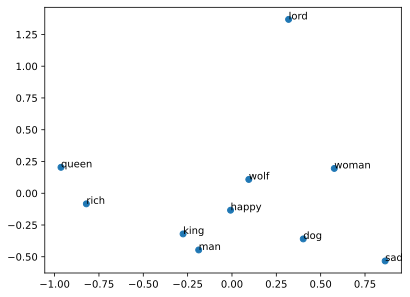

In [42]:
result= compute_pca(X, 2)
pyplot.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(words):
    pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))
pyplot.show()

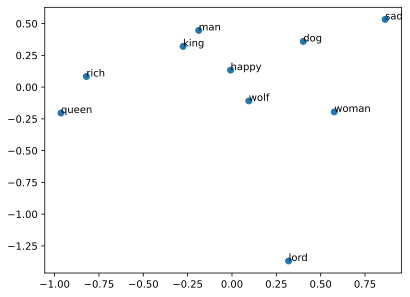

In [47]:
result= compute_pca(X, 4)
pyplot.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(words):
    pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))
pyplot.show()